# PCA Dimensionality Reduction

In order to lower the complexity of the data being fed into our models and to try and distill the weather features in our data, we will implement PCA on both the origin and destination weather features.

We will run two PCA models, one for destination weather and one for origin weather. That way, we can capture the variance across similar features and reduce down our overall feature space.

In [15]:
# Import libraries
import datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[0] / "src"))

from flight_delay_prediction.features import train_test_split_model_data

In [4]:
# Load model_df
model_df = pd.read_parquet(
    "../data/processed/cleaned_pre_encoding_data.parquet"
)

In [5]:
X_train, X_test, y_train, y_test = train_test_split_model_data(model_df)

## Preprocessing

 The first step in applying PCA is to extract the relevant features from the training and testing sets. 

In [6]:
# PCA for origin and dest weather features
X_train_dest_weather = X_train[['dest_temperature_2m_mean', 'dest_wind_speed_10m_max',
       'dest_wind_gusts_10m_max', 'dest_precipitation_sum', 'dest_rain_sum',
       'dest_snowfall_sum', 'dest_precipitation_hours', 'dest_temperature_2m_range']]

X_test_dest_weather = X_test[['dest_temperature_2m_mean', 'dest_wind_speed_10m_max',
       'dest_wind_gusts_10m_max', 'dest_precipitation_sum', 'dest_rain_sum',
       'dest_snowfall_sum', 'dest_precipitation_hours', 'dest_temperature_2m_range']]

X_train_origin_weather = X_train[['origin_wind_speed_10m_max', 'origin_wind_gusts_10m_max',
       'origin_precipitation_sum', 'origin_rain_sum', 'origin_snowfall_sum',
       'origin_precipitation_hours', 'origin_temperature_2m_range']]

X_test_origin_weather = X_test[['origin_wind_speed_10m_max', 'origin_wind_gusts_10m_max',
       'origin_precipitation_sum', 'origin_rain_sum', 'origin_snowfall_sum',
       'origin_precipitation_hours', 'origin_temperature_2m_range']]


In [11]:
# Initialize scalers
dest_scaler = StandardScaler()
origin_scaler = StandardScaler()

# Fit & transform scaler on training data
scaled_X_train_dest = dest_scaler.fit_transform(X_train_dest_weather)
scaled_X_train_origin = origin_scaler.fit_transform(X_train_origin_weather)

# Fit PCA on scaled train
dest_PCA = PCA()
origin_PCA = PCA()

dest_PCA.fit(scaled_X_train_dest)
origin_PCA.fit(scaled_X_train_origin)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [13]:
# Initializing the explained_variance_ratios
dest_explained_variance_ratios = dest_PCA.explained_variance_ratio_
origin_explained_variance_ratios = origin_PCA.explained_variance_ratio_

# Calculating the cumulative sum
dest_cum_evr = np.cumsum(dest_explained_variance_ratios)
origin_cum_evr = np.cumsum(origin_explained_variance_ratios)

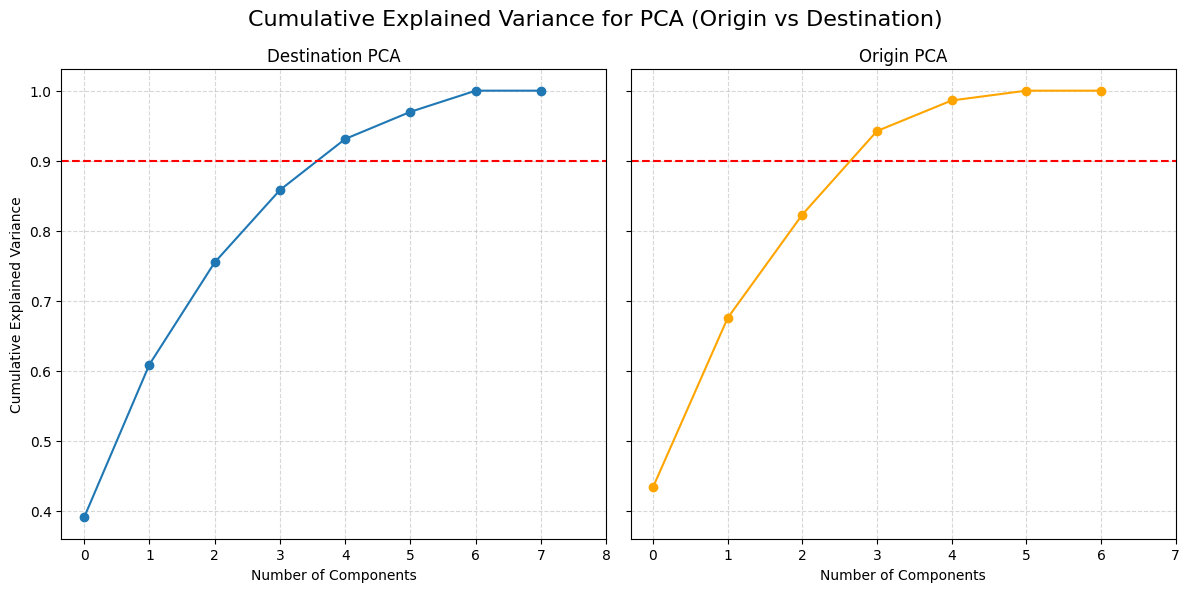

In [16]:
# Create side-by-side plots
fig, axes = plt.subplots(ncols=2, figsize=(12,6), sharey=True)

# Destination PCA EVR
axes[0].plot(dest_cum_evr, marker='o')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('Destination PCA')
axes[0].axhline(y=0.9, color='r', linestyle='--')
axes[0].set_xticks(np.arange(0, len(dest_explained_variance_ratios)+1, 1))
axes[0].grid(True, linestyle='--', alpha=0.5)

# Origin PCA EVR
axes[1].plot(origin_cum_evr, marker='o', color='orange')
axes[1].set_xlabel('Number of Components')
axes[1].set_title('Origin PCA')
axes[1].axhline(y=0.9, color='r', linestyle='--')
axes[1].set_xticks(np.arange(0, len(origin_explained_variance_ratios)+1, 1))
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Cumulative Explained Variance for PCA (Origin vs Destination)', fontsize=16)
plt.tight_layout()
plt.show()

In [17]:
# Create final PCA objects
final_dest_PCA = PCA(n_components = 4)
final_origin_PCA = PCA(n_components = 3)

# Fit transform on scaled training
PCA_X_train_dest = final_dest_PCA.fit_transform(scaled_X_train_dest)
PCA_X_train_origin = final_origin_PCA.fit_transform(scaled_X_train_origin)

PCA_X_train_dest_df = pd.DataFrame(PCA_X_train_dest,
                           columns=[f"dest_PC{i+1}" for i in range(PCA_X_train_dest.shape[1])])

PCA_X_train_origin_df = pd.DataFrame(PCA_X_train_origin,
                             columns=[f"origin_PC{i+1}" for i in range(PCA_X_train_origin.shape[1])])

# Use fitted scaler to transform test sets
scaled_X_test_dest = dest_scaler.transform(X_test_dest_weather)
scaled_X_test_origin = origin_scaler.transform(X_test_origin_weather)

# Run fitted PCA on scaled test sets
PCA_X_test_dest = final_dest_PCA.transform(scaled_X_test_dest)
PCA_X_test_origin = final_origin_PCA.transform(scaled_X_test_origin)

PCA_X_test_dest_df = pd.DataFrame(PCA_X_test_dest,
                           columns=[f"dest_PC{i+1}" for i in range(PCA_X_test_dest.shape[1])])

PCA_X_test_origin_df = pd.DataFrame(PCA_X_test_origin,
                             columns=[f"origin_PC{i+1}" for i in range(PCA_X_test_origin.shape[1])])

# Reconstruct X_train, X_test with PCA features
X_train_no_weather = X_train.drop(columns = ['dest_temperature_2m_mean', 'dest_wind_speed_10m_max',
                                             'dest_wind_gusts_10m_max', 'dest_precipitation_sum',
                                             'dest_rain_sum', 'dest_snowfall_sum', 'dest_precipitation_hours',
                                             'dest_temperature_2m_range', 'origin_wind_speed_10m_max',
                                             'origin_wind_gusts_10m_max','origin_precipitation_sum',
                                             'origin_rain_sum', 'origin_snowfall_sum','origin_precipitation_hours',
                                             'origin_temperature_2m_range'])

X_test_no_weather = X_test.drop(columns = ['dest_temperature_2m_mean', 'dest_wind_speed_10m_max',
                                             'dest_wind_gusts_10m_max', 'dest_precipitation_sum',
                                             'dest_rain_sum', 'dest_snowfall_sum', 'dest_precipitation_hours',
                                             'dest_temperature_2m_range', 'origin_wind_speed_10m_max',
                                             'origin_wind_gusts_10m_max','origin_precipitation_sum',
                                             'origin_rain_sum', 'origin_snowfall_sum','origin_precipitation_hours',
                                             'origin_temperature_2m_range'])

X_train_PCA = pd.concat([
    X_train_no_weather.reset_index(drop=True),
    PCA_X_train_dest_df.reset_index(drop=True),
    PCA_X_train_origin_df.reset_index(drop=True)],
                        axis = 1)
X_test_PCA = pd.concat([X_test_no_weather.reset_index(drop=True),
                        PCA_X_test_dest_df.reset_index(drop=True),
                        PCA_X_test_origin_df.reset_index(drop=True)],
                       axis = 1)

After creating the X arrays with our principal components, we will combine the X arrays with their respective labels and save them to `data/processed/PCA` as parquet files. These files will specifically only be used for PCA-based logistic regression analysis in the model experimentation notebook.

In [ ]:
# Create combined dfs
train_PCA_df = pd.concat([X_train_PCA, y_train.reset_index(drop=True)], axis = 1)
test_PCA_df = pd.concat([X_test_PCA, y_test.reset_index(drop=True)], axis = 1)

In [31]:
# Write to PCA dir in data/processed
pca_dir = Path().cwd().parent / "data/processed/PCA"
pca_dir.mkdir(parents = True, exist_ok = True)

train_PCA_df.to_parquet(pca_dir / "train.parquet")
test_PCA_df.to_parquet(pca_dir / "test.parquet")